# Bài thực hành: Tìm kiếm heuristic

## Ví dụ mẫu
Trong ví dụ này, chúng ta triển khai chiến lược Best-First Search trên một đồ thị đơn giản:

- Tạo đồ thị mẫu với trọng số
- Định nghĩa hàm đánh giá (heuristic)
- Cài đặt Best-First Search

In [1]:
import networkx as nx
import heapq

# Tạo đồ thị mẫu
G = nx.Graph()
edges = [
    ('A','B',2), ('A','C',3), ('B','D',4),
    ('C','D',1), ('B','E',5), ('D','E',1)
]
G.add_weighted_edges_from(edges)

# Hàm đánh giá heuristic (ước lượng chi phí đến đích)
def heuristic(u, goal):
    h = {'A':4, 'B':3, 'C':2, 'D':1, 'E':0}
    return h.get(u, float('inf'))

# Cài đặt Best-First Search
def best_first_search(graph, start, goal):
    visited = set()
    pq = []
    heapq.heappush(pq, (heuristic(start, goal), start))
    while pq:
        cost, node = heapq.heappop(pq)
        if node == goal:
            return True
        if node in visited:
            continue
        visited.add(node)
        for neighbor in graph.neighbors(node):
            if neighbor not in visited:
                heapq.heappush(pq, (heuristic(neighbor, goal), neighbor))
    return False

print("Best-First Search tìm thấy E từ A?:", best_first_search(G, 'A', 'E'))

Best-First Search tìm thấy E từ A?: True


## Bài tập thực hành
Bài 1. **Best-First Search**: Áp dụng chiến lược Best-First Search để tìm đường từ nút `A` đến `E` trên đồ thị mẫu trên, in ra thứ tự duyệt.

Thứ tự duyệt: ['A', 'B', 'E']


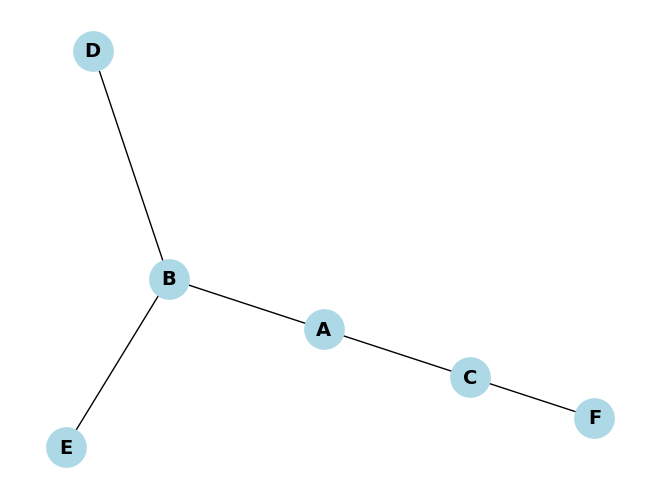

In [2]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# Tạo đồ thị mẫu
G = nx.Graph()
edges = [
    ('A','B'), ('A','C'),
    ('B','D'), ('B','E'),
    ('C','F')
]
G.add_edges_from(edges)

# heuristic (hàm đánh giá khoảng cách ước lượng tới E)
heuristic = {
    'A': 5,
    'B': 3,
    'C': 4,
    'D': 6,
    'E': 0,  # Đích
    'F': 7
}

def best_first_search(start, goal):
    visited = []
    pq = []  # priority queue
    heapq.heappush(pq, (heuristic[start], start))

    while pq:
        h, node = heapq.heappop(pq)
        if node not in visited:
            visited.append(node)

            if node == goal:
                break

            for neighbor in G.neighbors(node):
                if neighbor not in visited:
                    heapq.heappush(pq, (heuristic[neighbor], neighbor))
    return visited

# Thực hiện Best-First Search
order = best_first_search('A','E')
print("Thứ tự duyệt:", order)

# Vẽ đồ thị
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=800, font_size=14, font_weight='bold')
plt.show()


Bài 2. **Greedy Best-First Search**: Cài đặt Greedy Best-First Search và so sánh với Best-First Search.

Greedy Best-First Search: ['A', 'B', 'E']
Best-First Search: ['A', 'B', 'E']


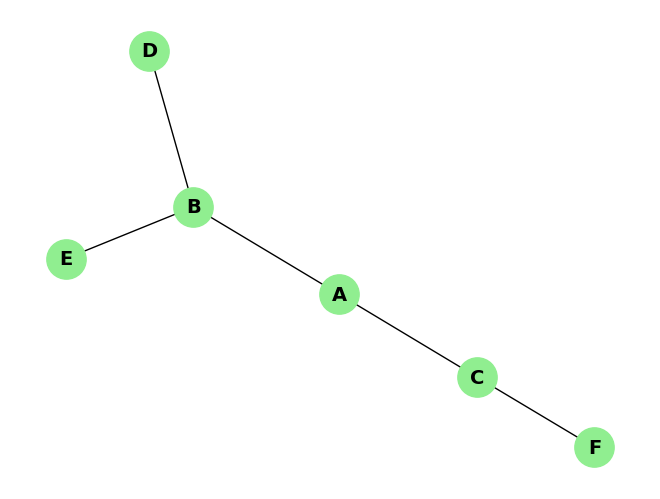

In [3]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# Đồ thị mẫu
G = nx.Graph()
edges = [
    ('A','B'), ('A','C'),
    ('B','D'), ('B','E'),
    ('C','F')
]
G.add_edges_from(edges)

# heuristic (ước lượng đến goal E)
heuristic = {
    'A': 5,
    'B': 3,
    'C': 4,
    'D': 6,
    'E': 0,
    'F': 7
}

def greedy_best_first_search(start, goal):
    visited = []
    frontier = [(heuristic[start], start)]

    while frontier:
        frontier.sort()  # sắp xếp theo h(n)
        h, node = frontier.pop(0)

        if node not in visited:
            visited.append(node)
            if node == goal:
                break
            for neighbor in G.neighbors(node):
                if neighbor not in visited:
                    frontier.append((heuristic[neighbor], neighbor))
    return visited

def best_first_search(start, goal):
    visited = []
    pq = []
    heapq.heappush(pq, (heuristic[start], start))

    while pq:
        h, node = heapq.heappop(pq)
        if node not in visited:
            visited.append(node)
            if node == goal:
                break
            for neighbor in G.neighbors(node):
                if neighbor not in visited:
                    heapq.heappush(pq, (heuristic[neighbor], neighbor))
    return visited

# So sánh kết quả
gbfs_order = greedy_best_first_search('A','E')
bfs_order = best_first_search('A','E')

print("Greedy Best-First Search:", gbfs_order)
print("Best-First Search:", bfs_order)

# Vẽ đồ thị
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=800, font_size=14, font_weight='bold')
plt.show()


Bài 3. **Hill Climbing**: Cài đặt chiến lược Hill Climbing với hàm đánh giá heuristic, kiểm tra khả năng thoát khỏi cực trị cục bộ.


Đường đi Hill Climbing: ['A', 'C']


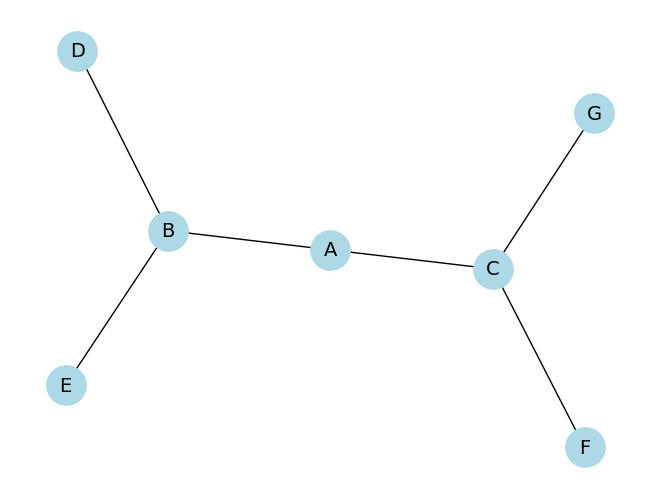

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

# Tạo đồ thị ví dụ
G = nx.Graph()
edges = [
    ('A','B'), ('A','C'),
    ('B','D'), ('B','E'),
    ('C','F'), ('C','G')
]
G.add_edges_from(edges)

# heuristic (đến goal = E)
heuristic = {
    'A': 7,
    'B': 6,
    'C': 2,
    'D': 5,
    'E': 0,  # goal
    'F': 3,
    'G': 4
}

def hill_climbing(start, goal):
    current = start
    path = [current]

    while current != goal:
        neighbors = list(G.neighbors(current))
        if not neighbors:
            break

        # chọn neighbor có heuristic tốt nhất
        next_node = min(neighbors, key=lambda x: heuristic[x])

        # nếu tốt hơn thì đi, nếu không thì dừng (kẹt cực trị cục bộ)
        if heuristic[next_node] < heuristic[current]:
            current = next_node
            path.append(current)
        else:
            break

    return path

# Test
hc_path = hill_climbing('A','E')
print("Đường đi Hill Climbing:", hc_path)

# Vẽ đồ thị
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=800, font_size=14)
labels = {n: f"{n}\nh={heuristic[n]}" for n in G.nodes}
plt.show()

Bài 4. **Beam Search**: Cài đặt Beam Search với kích thước chùm (`beam_width=2`) và so sánh hiệu năng với Hill Climbing.

In [6]:
def beam_search(start, goal, beam_width=2):
    frontier = [[start]]
    while frontier:
        new_frontier = []
        for path in frontier:
            node = path[-1]
            if node == goal:
                return path
            for neighbor in G.neighbors(node):
                if neighbor not in path:  # tránh lặp
                    new_frontier.append(path + [neighbor])

        # Sắp xếp theo heuristic và chỉ giữ lại beam_width đường đi tốt nhất
        new_frontier.sort(key=lambda p: heuristic[p[-1]])
        frontier = new_frontier[:beam_width]
    return None

# Test
beam_path = beam_search('A','E', beam_width=2)
print("Đường đi Beam Search:", beam_path)

Đường đi Beam Search: ['A', 'B', 'E']
